# Benchmark Memory Plots

This notebook plots GPU and CPU memory usage captured by `benchmark/run_bench.py --monitor-mem`.

It reads CSV files from `benchmark/results/` and shows time-series curves.

In [138]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

plt.style.use("seaborn-v0_8")


In [139]:
from pathlib import Path

# Resolve benchmark/results from common working directories.
cwd = Path.cwd()
candidates = [
    cwd / "benchmark" / "results",
    cwd / "results",
    cwd.parent / "benchmark" / "results",
]
results_dir = None
for candidate in candidates:
    if candidate.exists():
        results_dir = candidate
        break

if results_dir is None:
    raise FileNotFoundError("Could not find benchmark/results; set results_dir manually.")
results_dir


PosixPath('benchmark/results')

In [140]:
# Pick the latest tag for HF and Monitoring runs (new format).
gpu_hf_files = sorted(results_dir.glob("gpu_mem_hf_*.csv"))
cpu_hf_files = sorted(results_dir.glob("cpu_mem_hf_*.csv"))
gpu_mon_files = sorted(results_dir.glob("gpu_mem_monitoring_*.csv"))
cpu_mon_files = sorted(results_dir.glob("cpu_mem_monitoring_*.csv"))

gpu_hf_csv = str(gpu_hf_files[-1]) if gpu_hf_files else None
cpu_hf_csv = str(cpu_hf_files[-1]) if cpu_hf_files else None
gpu_mon_csv = str(gpu_mon_files[-1]) if gpu_mon_files else None
cpu_mon_csv = str(cpu_mon_files[-1]) if cpu_mon_files else None

print("HF GPU CSV:", gpu_hf_csv)
print("HF CPU CSV:", cpu_hf_csv)
print("Monitoring GPU CSV:", gpu_mon_csv)
print("Monitoring CPU CSV:", cpu_mon_csv)

tag = None
if gpu_hf_csv is not None:
    tag = Path(gpu_hf_csv).stem.replace("gpu_mem_hf_", "")
elif gpu_mon_csv is not None:
    tag = Path(gpu_mon_csv).stem.replace("gpu_mem_monitoring_", "")

summary = None
if tag is not None:
    summary_path = results_dir / f"summary_{tag}.json"
    if summary_path.exists():
        summary = json.loads(summary_path.read_text())
        print("Summary:", summary_path)


HF GPU CSV: benchmark/results/gpu_mem_hf_20260128_191929.csv
HF CPU CSV: benchmark/results/cpu_mem_hf_20260128_191929.csv
Monitoring GPU CSV: benchmark/results/gpu_mem_monitoring_20260128_191929.csv
Monitoring CPU CSV: benchmark/results/cpu_mem_monitoring_20260128_191929.csv
Summary: benchmark/results/summary_20260128_191929.json


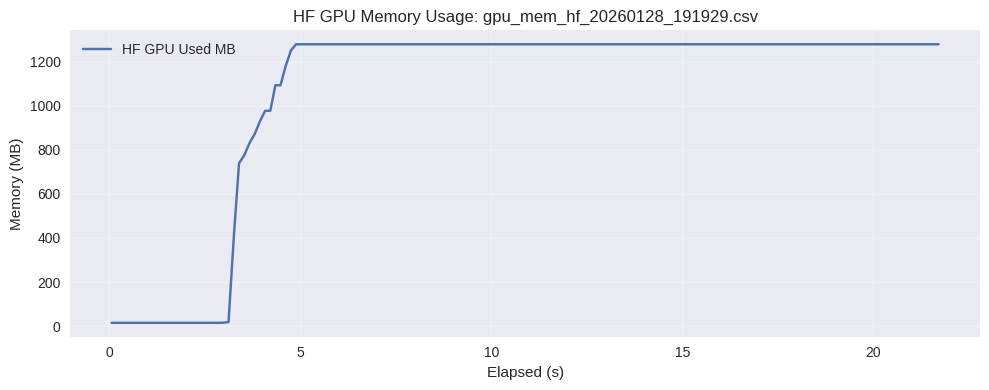

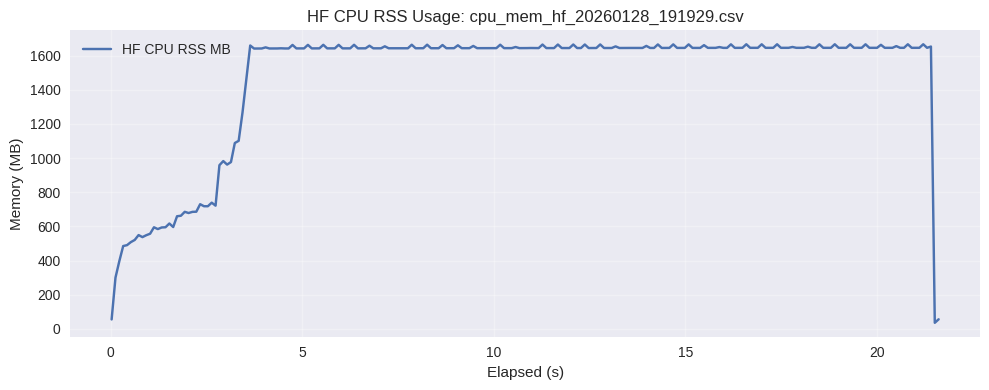

In [141]:
if gpu_hf_csv is None or cpu_hf_csv is None:
    raise FileNotFoundError("HF GPU/CPU CSV not found in results_dir")

gpu_df = pd.read_csv(gpu_hf_csv)
cpu_df = pd.read_csv(cpu_hf_csv)

if "epoch_s" in gpu_df.columns and "epoch_s" in cpu_df.columns and summary and summary.get("hf_start_ts"):
    t0 = float(summary["hf_start_ts"])
    gpu_df["elapsed_s"] = gpu_df["epoch_s"] - t0
    cpu_df["elapsed_s"] = cpu_df["epoch_s"] - t0
else:
    gpu_df["timestamp"] = pd.to_datetime(gpu_df["timestamp"], errors="coerce")
    cpu_df["timestamp"] = pd.to_datetime(cpu_df["timestamp"], errors="coerce")
    gpu_df = gpu_df.dropna(subset=["timestamp"])
    cpu_df = cpu_df.dropna(subset=["timestamp"])
    t0 = min(gpu_df["timestamp"].min(), cpu_df["timestamp"].min())
    gpu_df["elapsed_s"] = (gpu_df["timestamp"] - t0).dt.total_seconds()
    cpu_df["elapsed_s"] = (cpu_df["timestamp"] - t0).dt.total_seconds()

gpu_df = gpu_df[gpu_df["elapsed_s"] >= 0]
cpu_df = cpu_df[cpu_df["elapsed_s"] >= 0]

plt.figure(figsize=(10, 4))
plt.plot(gpu_df["elapsed_s"], gpu_df["memory_used_mb"], label="HF GPU Used MB")
plt.xlabel("Elapsed (s)")
plt.ylabel("Memory (MB)")
plt.title(f"HF GPU Memory Usage: {Path(gpu_hf_csv).name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cpu_df["elapsed_s"], cpu_df["rss_mb"], label="HF CPU RSS MB")
plt.xlabel("Elapsed (s)")
plt.ylabel("Memory (MB)")
plt.title(f"HF CPU RSS Usage: {Path(cpu_hf_csv).name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


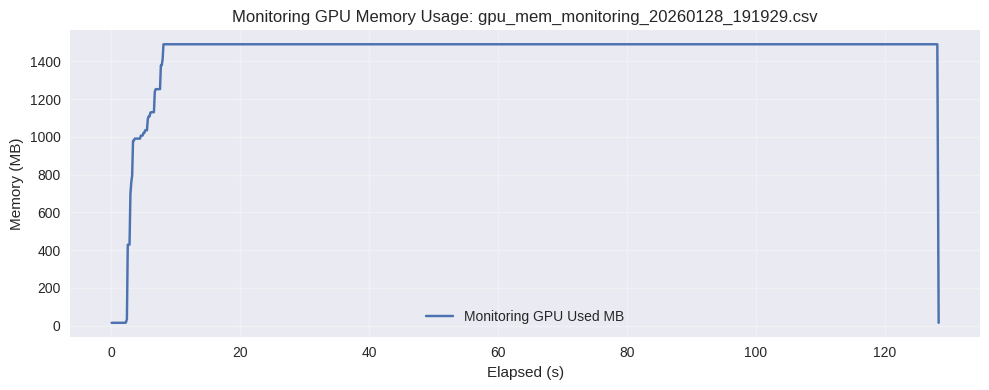

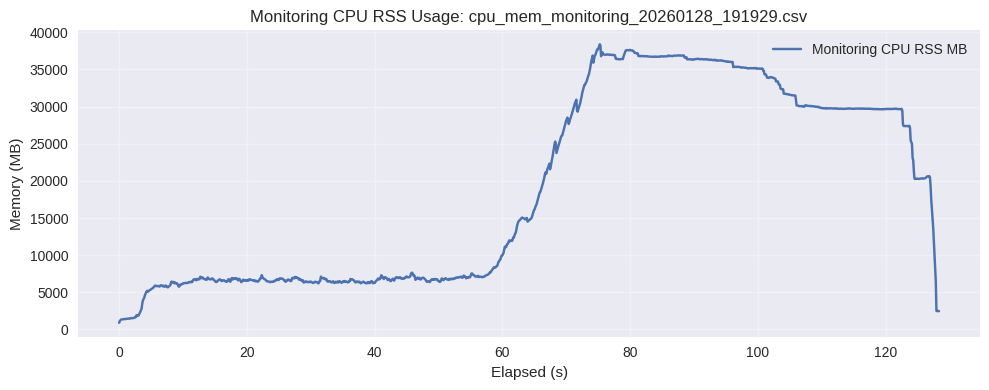

In [142]:
if gpu_mon_csv is None or cpu_mon_csv is None:
    raise FileNotFoundError("Monitoring GPU/CPU CSV not found in results_dir")

gpu_df = pd.read_csv(gpu_mon_csv)
cpu_df = pd.read_csv(cpu_mon_csv)

if "epoch_s" in gpu_df.columns and "epoch_s" in cpu_df.columns and summary and summary.get("monitoring_start_ts"):
    t0 = float(summary["monitoring_start_ts"])
    gpu_df["elapsed_s"] = gpu_df["epoch_s"] - t0
    cpu_df["elapsed_s"] = cpu_df["epoch_s"] - t0
else:
    gpu_df["timestamp"] = pd.to_datetime(gpu_df["timestamp"], errors="coerce")
    cpu_df["timestamp"] = pd.to_datetime(cpu_df["timestamp"], errors="coerce")
    gpu_df = gpu_df.dropna(subset=["timestamp"])
    cpu_df = cpu_df.dropna(subset=["timestamp"])
    t0 = min(gpu_df["timestamp"].min(), cpu_df["timestamp"].min())
    gpu_df["elapsed_s"] = (gpu_df["timestamp"] - t0).dt.total_seconds()
    cpu_df["elapsed_s"] = (cpu_df["timestamp"] - t0).dt.total_seconds()

gpu_df = gpu_df[gpu_df["elapsed_s"] >= 0]
cpu_df = cpu_df[cpu_df["elapsed_s"] >= 0]

plt.figure(figsize=(10, 4))
plt.plot(gpu_df["elapsed_s"], gpu_df["memory_used_mb"], label="Monitoring GPU Used MB")
plt.xlabel("Elapsed (s)")
plt.ylabel("Memory (MB)")
plt.title(f"Monitoring GPU Memory Usage: {Path(gpu_mon_csv).name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cpu_df["elapsed_s"], cpu_df["rss_mb"], label="Monitoring CPU RSS MB")
plt.xlabel("Elapsed (s)")
plt.ylabel("Memory (MB)")
plt.title(f"Monitoring CPU RSS Usage: {Path(cpu_mon_csv).name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
